## SVR

Support Vector Regression [1] is an optimization problem based on the same principles as SVM, but aimed for regression problems. The basic SVR formulation is:

\begin{equation*}
\begin{alignat*}{2}
&\!\min_{f \in \mathcal{H},b \in \mathbb{R}^N} &\qquad&  C \sum\limits_{i=1}^N \max(0, y_i - \epsilon - (f(x_i) + b)) + \max(0, f(x_i) + b - (y_i + \epsilon)) + \frac{1}{2}||f||_{\mathcal{H}}^2,\\
\end{alignat*}
\end{equation*}
where $C$ and $\epsilon$ are respectively the regularization and tube width parameters. They are chosen by the operator.

After the introduction of slack variables $\xi_i, \xi_i^\star$ to have a soft-margin and make the problem feasible whatever the points configuration, the problem is trivially equivalent to:

\begin{equation*}
\begin{alignat*}{3}
&\!\min_{f \in \mathcal{H},b \in \mathbb{R},\xi, \xi^\star \in \mathbb{R}^N} &\qquad& C\sum_{i = 1}^N \xi_i + \xi_i^\star + \frac{1}{2}||f||_{\mathcal{H}}^2\\
&\text{subject to} &      & f(x_i) + b - y_i \leq \xi_i + \epsilon \quad \forall i \in \{1, \cdots, N\} & \text{lower bound}\\
&                  &      & y_i - f(x_i) - b \leq \xi_i^\star + \epsilon \quad \forall i \in \{1, \cdots, N\} & \text{upper bound}\\
&                  &      & \xi_i \geq 0, \xi_i^\star \geq 0 \quad \forall i \in \{1, \cdots, N\} \\
\end{alignat*}
\end{equation*}

The first constraint ensures that the data points is not too far from below, and the second constraint that it is not to far from above. The representer theorem can be applied, let $f(x)=\sum\limits_{i=1}^N \beta_i K(x_i,x) + b$. After pluging it, 

The dual problem is [1,2]:
\begin{equation*}
\begin{alignat*}{2}
&\!\min_{\alpha, \alpha^\star \in \mathbb{R}^N} &\qquad& (\alpha - \alpha^\star)^\top K(\alpha - \alpha^\star) + \epsilon e^\top (\alpha + \alpha^\star) - y^\top (\alpha - \alpha^\star)\\
&\text{subject to} &      & e^\top(\alpha - \alpha^\star) = 0 \\
&                  &      & \alpha_i \geq 0; \alpha_i \leq C\quad \forall i \in \{1, \cdots, N\}, \\
&                  &      & \alpha_i^\star \geq 0; \alpha_i^\star \leq C\quad \forall i \in \{1, \cdots, N\}, \\
\end{alignat*}
\end{equation*}
with $e = (1, \cdots, 1)^\top$ and $\alpha, \alpha^\star$ the Lagrange multiplier of the two first sets of constraints in primal formulation. It can also be solved quite easily via a quadratic solver. $K$ is the Gram matrix: $(K_{i,j})_{i, j \in \{1, \cdots, N\}}=(K(x_i, x_j))_{i, j \in \{1, \cdots, N\}}$. One can show that the expansion's coefficients are related to Lagrange's multipliers: $\beta_i = \alpha_i-\alpha^\star_i$ [2]. Also $b$ is chosen as: $b=\max\limits_i \{-\epsilon + y_i -f(x_i) | \alpha_i<C, \alpha_i^\star >0\}=\min\limits_i \{-\epsilon + y_i -f(x_i) | \alpha_i>0, \alpha_i^\star <C\}$. And if $\alpha_i \in (0,C)$, then $b=-\epsilon + y_i -f(x_i)=y_i - \epsilon - \sum\limits_{j=1}^N (\alpha_i - \alpha_i^\star)K(x, x_i)$.

For resolution, I'll use the same quadratic solver as for PCA, i.e., *Sequential Least Square Quadratic Programming* (SLSQP), one of the only algorithm I know that can handle both equality and inequality constraints.


[1] https://alex.smola.org/papers/2004/SmoSch04.pdf

[2] https://proceedings.neurips.cc/paper_files/paper/1996/file/d38901788c533e8286cb6400b40b386d-Paper.pdf

In [ ]:
from sklearn.base import RegressorMixin, BaseEstimator
import numpy as np
from scipy.optimize import fmin_slsqp
import matplotlib.pyplot as plt

def Linear(gamma: float=None, c: float=None):
    def kernel(x: np.ndarray, y: np.ndarray, on_diagonal: bool=False):
        #Vectorize scalar product
        if len(x.shape) == len(y.shape) and len(x.shape) > 1:
            if on_diagonal:
                return np.einsum('ij, ij -> i', x, y)
            return np.einsum('ij, kj -> ik', x, y)
        return x @ y.T
    return kernel

def RBF(gamma: float = 1, c: float=None):
    def kernel(x: np.ndarray, y: np.ndarray, on_diagonal: bool=False):
        if len(x.shape)==1 or len(y.shape)==1:
            on_diagonal=True
        if on_diagonal:
            expo=-(np.sum((x - y)**2, axis = -1))/(2*gamma) #Sum along data axis
        else:
            expo = -(np.sum((x[:,None,:] - y[None,:,:])**2, axis = -1))/(2*gamma) #Sum along data dimension
        return np.exp(expo)
    return kernel

def poly(gamma: int, c:float=1):
    assert type(gamma)==int, "Power parameter should be an integer."
    lin=Linear()
    def kernel(x, y, on_diagonal: bool=False):
        return np.pow((c + lin(x, y, on_diagonal)), gamma)
    return kernel

def sigmoid(gamma: float=1, c: float=1):
    lin=Linear()
    def kernel(x: np.ndarray, y: np.ndarray, on_diagonal: bool=False):
        return np.tanh(gamma*lin(x, y, on_diagonal) + c)
    return kernel

dict_kernel=dict({"linear": Linear, "gaussian": RBF, "polynomial": poly})

class SVR(RegressorMixin, BaseEstimator):
    def __init__(self, epsilon: float, C:float, kernel: str, gamma: float=1, c: float=None):
        self.epsilon=epsilon
        self.C=C
        assert C > 0, "C should be positive."
        self.kernel=dict_kernel.get(kernel)(gamma, c)
        self.is_fitted=False
        self.X=None

    def fit(self, X: np.ndarray, y: np.ndarray):
        N=len(X)
        self.X=X
        e=np.ones(N)
        assert len(X)==len(y), "X and y should have the same number of elements."
        K=self.kernel(X, X)
        alpha=np.ones(N)*self.C/2
        alpha_star=np.ones(N)*self.C/2
        Alpha_c=np.concatenate((alpha, alpha_star), axis=0)

        def loss(Alpha_c: np.ndarray):
            alpha, alpha_star=Alpha_c[:N], Alpha_c[N:]
            return (alpha-alpha_star)@K@(alpha-alpha_star) + self.epsilon * e @ (alpha + alpha_star) - (alpha-alpha_star)@y

        def grad_loss(Alpha_c: np.ndarray):
            alpha, alpha_star=Alpha_c[:N], Alpha_c[N:]
            part_1=K@(alpha - alpha_star) + self.epsilon*e - y
            part_2=K@(alpha_star - alpha) + self.epsilon*e + y
            return np.concatenate((part_1[None,...], part_2[None,...]), axis=1)

        def eqcons(Alpha_c: np.ndarray):
            alpha, alpha_star=Alpha_c[:N], Alpha_c[N:]
            return e@(alpha-alpha_star)

        def grad_eqcons(Alpha_c: np.ndarray):
            return np.concatenate((e[None,...], -e[None,...]), axis=1)

        def ieqcons(Alpha_c: np.ndarray):
            alpha, alpha_star=Alpha_c[:N], Alpha_c[N:]
            return np.concatenate((alpha, self.C - alpha, alpha_star, self.C - alpha_star), axis=0)

        def grad_ieqcons(Alpha_c: np.ndarray):
            bloc1=np.concatenate((np.eye(N), np.zeros((N,N))), axis=1)
            bloc2=np.concatenate((np.zeros((N,N)), np.eye(N)), axis=1)
            return np.concatenate((bloc1, -bloc1, bloc2, -bloc2), axis=0)

        Alpha_c=fmin_slsqp(func=loss, x0=Alpha_c, f_eqcons=eqcons, f_ieqcons=ieqcons, \
            fprime=grad_loss, fprime_eqcons=grad_eqcons, fprime_ieqcons=grad_ieqcons)

        alpha, alpha_star=Alpha_c[:N], Alpha_c[N:]
        idx=np.where(alpha < 1e-9)[0]
        alpha[idx]=0
        idx=np.where(self.C - alpha < 1e-9)[0]
        alpha[idx]=self.C

        idx=np.where(((alpha>0)&(alpha<self.C)))[0]

        if len(idx)==0:
            idx=np.where(alpha_star > 1e-9 and alpha < self.C)[0]
        idx=idx[0]

        self.beta=alpha-alpha_star
        self.b=y[idx] - self.epsilon - self.kernel(X[idx], X) @ self.beta

        self.is_fitted=True

    def predict(self, X_test: np.ndarray):
        return self.kernel(X_test, self.X)@self.beta + self.b

Optimization terminated successfully    (Exit mode 0)
            Current function value: -59.32270046851741
            Iterations: 13
            Function evaluations: 26
            Gradient evaluations: 13
1


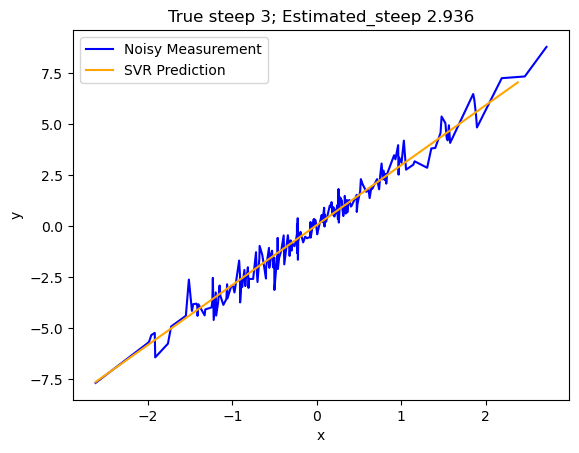

In [142]:
np.random.seed(42)

n_samples, n_features = 200, 1
X = np.random.randn(n_samples, n_features)
true_coef = 3

X.sort(axis=0)
y = X*3
# Add some noise
y += .5*np.random.normal(size=(n_samples, 1))
y=y.squeeze()
plt.plot(X, y, c='blue', label='Noisy Measurement')

X_test=np.arange(np.min(X), np.max(X), step=.5)[...,None]
svr=SVR(epsilon=.1, C=1, kernel="linear")
svr.fit(X,y)
y_test=svr.predict(X_test)
estimated_steep=(y_test[-1] - y_test[0])/(X_test[-1].item() - X_test[0].item())

plt.plot(X_test, y_test, c='orange', label="SVR Prediction")
plt.title(f"True steep {true_coef}; Estimated_steep {estimated_steep:.3f}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

Optimization terminated successfully    (Exit mode 0)
            Current function value: -55.355679211097666
            Iterations: 16
            Function evaluations: 35
            Gradient evaluations: 16
1


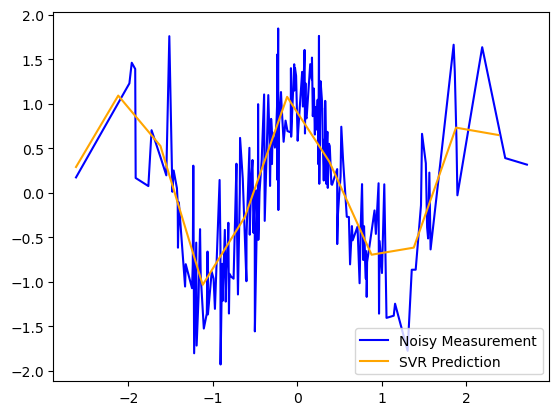

In [146]:
np.random.seed(42)

n_samples, n_features = 200, 1
X = np.random.randn(n_samples, n_features)
true_coef = 3

X.sort(axis=0)
y = np.cos(3*X)
# Add some noise
y += .5*np.random.normal(size=(n_samples, 1))
y=y.squeeze()
plt.plot(X, y, c='blue', label='Noisy Measurement')

X_test=np.arange(np.min(X), np.max(X), step=.5)[...,None]
svr=SVR(epsilon=.1, C=1, kernel="gaussian", gamma=.1)
svr.fit(X,y)
y_test=svr.predict(X_test)
estimated_steep=(y_test[-1] - y_test[0])/(X_test[-1].item() - X_test[0].item())

plt.plot(X_test, y_test, c='orange', label="SVR Prediction")
plt.legend()
plt.show()